In [1]:
%cd ../..

f:\nn


# Importing Libraries

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms

from tqdm import tqdm

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

from utils.training import train_model, evaluate_model
from utils.visualization import plot_training_curves, plot_confusion_matrix
from utils.dataset import CrackDataset
from utils.config import CNN_CONFIG, CNN_SEARCH_SPACE
from utils.hparam_search import run_search, plot_search_results

f:\nn\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Importing our dataset

,class,resized_path
0,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
1,Non Cracked,data\augmented_images\7050-6_resized_aug2.jpeg
2,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
3,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
4,Non Cracked,data\augmented_images\7119-100_resized_aug2.jpeg
5,Non Cracked,data\cracked_vs_non_cracked_resized\Non Cracke...
6,Non Cracked,data\augmented_images\14397_resized_aug0.jpeg
7,Non Cracked,data\augmented_images\16418_resized_aug0.jpeg
8,Non Cracked,data\augmented_images\047-50_resized_aug1.jpeg
9,Non Cracked,data\augmented_images\7103-214_resized_aug1.jpeg


Class distribution:


<Axes: xlabel='class'>

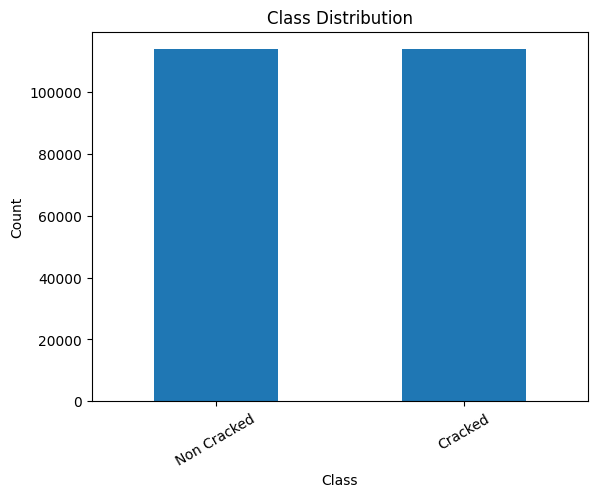

In [4]:
df = pd.read_csv('data/trainable_df.csv')
display(df.head(10))
print("="*80)
print("Class distribution:")
display(df['class'].value_counts().plot(kind='bar'))
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.show()

# Preparing our data

## Image resize

> For the CNN we resize images to 128×128. Unlike the FFNN which flattens the image into a 1D vector and the CNN which processes it row by row, a CNN applies convolutional filters that slide over the 2D image and explicitly exploit spatial relationships between neighbouring pixels. This makes CNNs naturally suited to image classification — they can detect local features like edges and textures regardless of where they appear in the image. The larger 128×128 resolution gives the convolutional layers more spatial detail to work with, and the channel dimension (1 for grayscale) is preserved since `nn.Conv2d` expects input of shape `(batch, channels, height, width)`.

In [5]:
transformations = transforms.Compose([
    transforms.Resize((CNN_CONFIG['image_size'], CNN_CONFIG['image_size'])),
    transforms.ToTensor(),                        # (H, W) → (1, H, W)
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

classes = sorted(df['class'].unique())
dataset = CrackDataset(df, transform=transformations, classes=classes)

n = len(dataset)
train_dataset = int(n * 0.8)
val_dataset   = int(n * 0.1)
test_dataset  = n - train_dataset - val_dataset
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_dataset, val_dataset, test_dataset],
    generator=torch.Generator().manual_seed(42))

print(f"Train: {len(train_dataset):,}  |  Val: {len(val_dataset):,}  |  Test: {len(test_dataset):,}")
print(f"Classes: {classes}")
print(f"Class→idx: {dataset.class_to_idx}")

Train: 182,297  |  Val: 22,787  |  Test: 22,788
Classes: ['Cracked', 'Non Cracked']
Class→idx: {'Cracked': 0, 'Non Cracked': 1}


# Initializing the DataLoader

The `DataLoader` wraps each split in a batched iterator. `shuffle=True` on the training set prevents the model from memorising sample order. Validation and test loaders use `shuffle=False` so metrics are fully reproducible.

In [7]:
train_loader = DataLoader(train_dataset, batch_size=CNN_CONFIG['batch_size'], shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=CNN_CONFIG['batch_size'], shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=CNN_CONFIG['batch_size'], shuffle=False, num_workers=0)

In [8]:
class CNN(nn.Module):
    """
    A CNN for binary crack classification.

    Architecture: three convolutional blocks (Conv → ReLU → MaxPool) that
    progressively downsample the spatial dimensions while increasing the number
    of feature maps, followed by a fully-connected classifier head.

    Input shape: (batch, 1, 128, 128) — grayscale images with channel dim.
    Output shape: (batch, num_classes)
    """

    def __init__(self, num_classes: int, dropout: float = 0.4):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: (1, 128, 128) → (32, 64, 64)
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: (32, 64, 64) → (64, 32, 32)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: (64, 32, 32) → (128, 16, 16)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),                          # (128, 16, 16) → (32768,)
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = CNN(num_classes=len(classes), dropout=CNN_CONFIG['dropout'])

# Optimizer and loss function

In [9]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=CNN_CONFIG['lr'],
    weight_decay=CNN_CONFIG['weight_decay']
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Training our data

## Training using our GPU

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Using device: {device}")

Using device: cuda


In [12]:
def build_cnn(params, num_classes):
    model     = CNN(
        num_classes=num_classes,
        dropout=params['dropout']
    )
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=params['lr'], weight_decay=params['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode='min', factor=0.5, patience=3)
    criterion = nn.CrossEntropyLoss()
    return model, optimizer, scheduler, criterion

In [13]:
best_params, trial_histories = run_search(
    build_cnn,
    train_loader, val_loader,
    CNN_SEARCH_SPACE, 
    classes,
    results_path='Models/CNN/best_hparams.json',
)

Pre-loading 54,689 samples into RAM...
Done.
Pre-loading 22,787 samples into RAM...
Done.

Trial 1/30 — lr=7.14e-04, weight_decay=1.36e-06, dropout=1.42e-01, batch_size=64


Epoch 1/50 [val]: 100%|██████████| 357/357 [00:03<00:00, 105.40it/s]

Epoch 1/50 | Train Loss: 0.5322 | Train Acc: 0.7051 | Val Loss: 0.4893 | Val Acc: 0.7345 | LR: 7.14e-04



Epoch 2/50 [val]: 100%|██████████| 357/357 [00:03<00:00, 106.42it/s]

Epoch 2/50 | Train Loss: 0.4813 | Train Acc: 0.7378 | Val Loss: 0.4828 | Val Acc: 0.7421 | LR: 7.14e-04


...


Epoch 10/50 [val]: 100%|██████████| 179/179 [00:03<00:00, 55.21it/s]

Epoch 10/50 | Train Loss: 0.3272 | Train Acc: 0.8288 | Val Loss: 0.4768 | Val Acc: 0.7550 | LR: 2.48e-04



Epoch 11/50 [val]: 100%|██████████| 179/179 [00:03<00:00, 55.27it/s]

Epoch 11/50 | Train Loss: 0.2797 | Train Acc: 0.8579 | Val Loss: 0.5212 | Val Acc: 0.7603 | LR: 2.48e-04
Early stopping at epoch 11 (no improvement for 5 epochs)
  -> best val_loss=0.4448 over 11 epochs



Best trial #28  val_loss=0.4235
Params: {'lr': 0.0010854684120321185, 'weight_decay': 0.0003723260655101923, 'dropout': 0.42329071963178416, 'batch_size': 32}
Saved to Models\CNN\best_hparams.json


# Plotting our training, validation losses

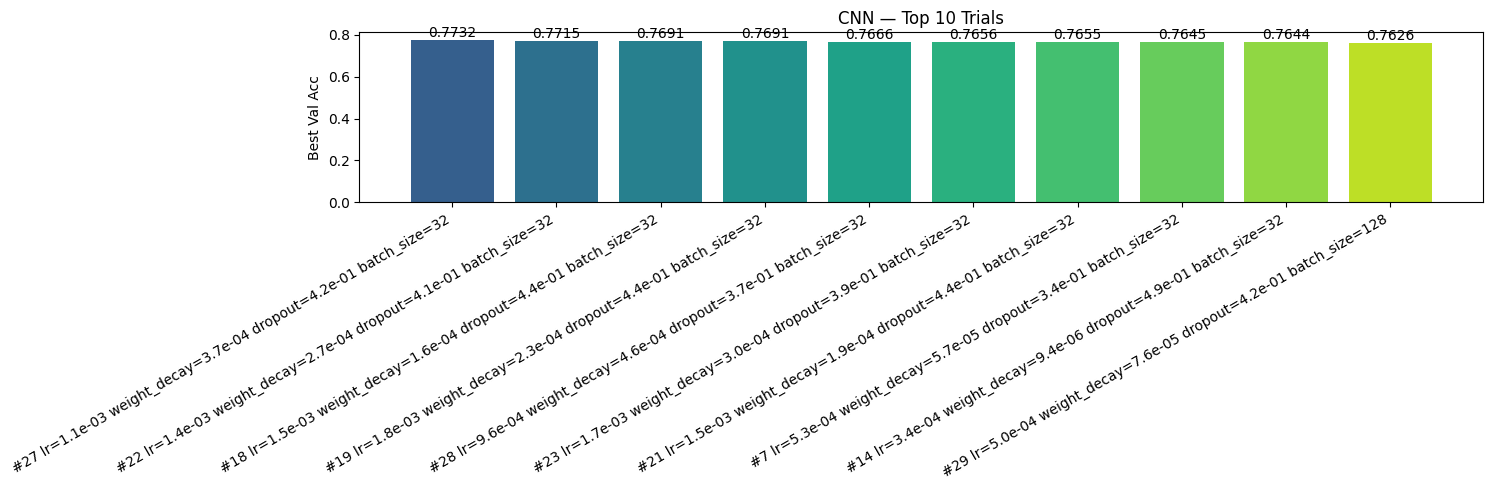

In [19]:
plot_search_results(trial_histories, metric='val_acc', title='CNN — Top 10 Trials', top_n=10)

# Evaluation

We reload the best checkpoint before running inference — `train_model` saves it during training but the `model` variable in memory holds the last epoch, not the best one.

In [14]:
CNN_CONFIG.update(best_params)
model = CNN(
    num_classes=len(classes),
    dropout=CNN_CONFIG['dropout']
)
optimizer = torch.optim.Adam(model.parameters(),
                              lr=CNN_CONFIG['lr'],
                              weight_decay=CNN_CONFIG['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [15]:
history = train_model(build_cnn, train_loader, val_loader,
                      params=best_params, num_classes=len(classes),
                      epochs=CNN_CONFIG['epochs'], device=device,
                      patience=CNN_CONFIG['patience'],
                      save_path='Models/saved_models/cnn_best.pth')

Epoch 1/150 [val]: 100%|██████████| 357/357 [00:14<00:00, 24.00it/s]

Epoch 1/150 | Train Loss: 0.5052 | Train Acc: 0.7258 | Val Loss: 0.4649 | Val Acc: 0.7512 | LR: 1.09e-03


  -> Saved best model (val_loss=0.4649)


Epoch 2/150 [val]: 100%|██████████| 357/357 [00:11<00:00, 31.45it/s]

Epoch 2/150 | Train Loss: 0.4649 | Train Acc: 0.7488 | Val Loss: 0.4451 | Val Acc: 0.7593 | LR: 1.09e-03


...

Epoch 61/150 | Train Loss: 0.3136 | Train Acc: 0.8341 | Val Loss: 0.3782 | Val Acc: 0.7892 | LR: 6.78e-05



Epoch 62/150 [val]: 100%|██████████| 357/357 [00:10<00:00, 32.89it/s]

Epoch 62/150 | Train Loss: 0.3068 | Train Acc: 0.8388 | Val Loss: 0.3837 | Val Acc: 0.7875 | LR: 6.78e-05



Epoch 63/150 [val]: 100%|██████████| 357/357 [00:08<00:00, 44.60it/s]

Epoch 63/150 | Train Loss: 0.3051 | Train Acc: 0.8402 | Val Loss: 0.3768 | Val Acc: 0.7930 | LR: 6.78e-05
Early stopping at epoch 63 (no improvement for 10 epochs)


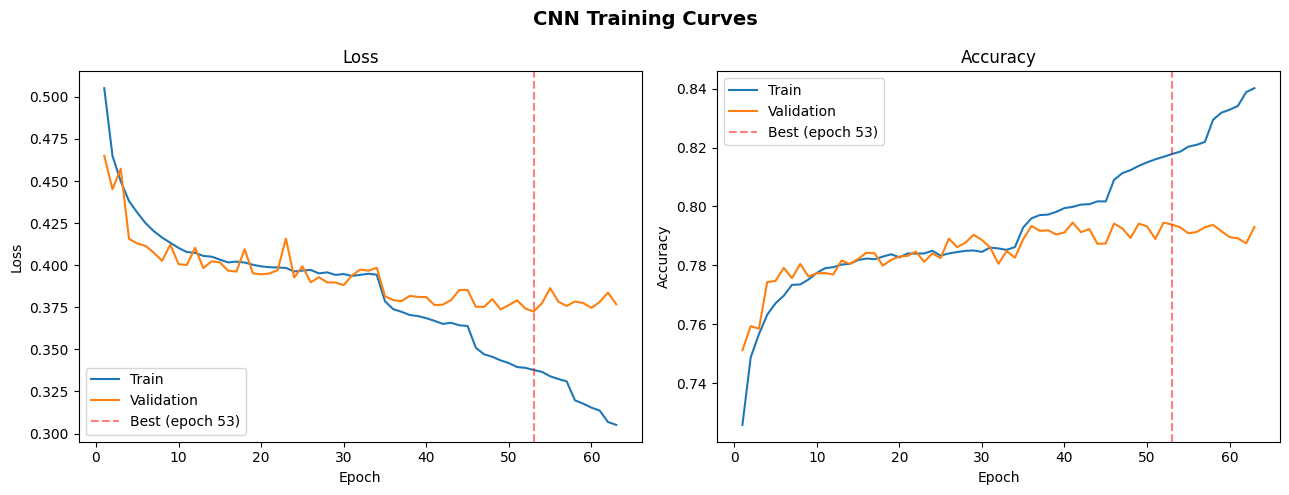

In [16]:
plot_training_curves(history, title="CNN Training Curves")

In [17]:
model = CNN(
    num_classes=len(classes), 
    dropout=CNN_CONFIG['dropout']
    )
checkpoint = torch.load('Models/saved_models/cnn_best.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']} "
      f"| val_loss={checkpoint['val_loss']:.4f} | val_acc={checkpoint['val_acc']:.4f}")
model.to(device)

Loaded best model from epoch 53 | val_loss=0.3725 | val_acc=0.7939


CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.42329071963178416, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)

Classification Report:
              precision    recall  f1-score   support

     Cracked       0.87      0.70      0.77     11341
 Non Cracked       0.75      0.89      0.81     11447

    accuracy                           0.80     22788
   macro avg       0.81      0.80      0.79     22788
weighted avg       0.81      0.80      0.79     22788



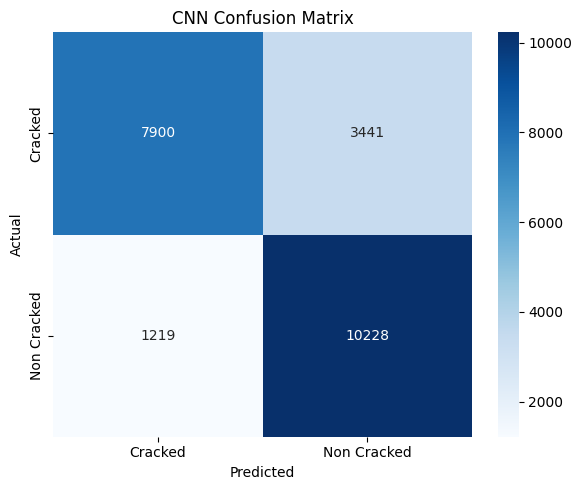

In [18]:
all_preds, all_labels = evaluate_model(model, test_loader, device=device)
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))
plot_confusion_matrix(all_labels, all_preds, class_names=classes, title='CNN Confusion Matrix')